# The "Hottest Month" Model — Complete Analysis & Documentation
**Market:** Kalshi `KXHMONTH` — *Will <month> 2026 be the hottest <month> ever?* (settles on the NOAA NCEI global land+ocean anomaly)
**Author:** Felipe Cardozo (model built with Claude) · **Built:** July 6, 2026 · **Re-runnable:** set `REFRESH=True` in the first code cell and *Run All*.

| § | Section |
|---|---------|
| 0 | The contract — what one number decides everything |
| 1 | Data: the fast signal (ERA5 daily) and the slow signal (NOAA monthly) |
| 2 | Aggregation, the warming trend, and where 2026 sits |
| 3 | The translation regression (ERA5 → NOAA): math, fit, residuals |
| 4 | From point estimate to probability: normal distribution, Z-score, tie band |
| 5 | July: forecasting an unfinished month + variance collapse (k-days) |
| 6 | The 2026 audit: testing the model on months NOAA already printed |
| 7 | Money: EV, fees, Kelly sizing |
| 8 | Summary card, limitations, operating calendar |

## §0 · The contract
- **Settlement source:** NOAA NCEI *Climate at a Glance*, Global Land+Ocean, 1-month anomaly (°C vs the 1901–2000 average), 2 decimals. Revisions after expiration are ignored.
- **YES wins** iff the month prints **strictly above** every prior same-calendar-month value. Current records: **June 2024 = +1.18°C, July 2024 = +1.18°C**. A print of 1.18 is a *tie* (ambiguous under the rules — tracked separately below).
- **Timing:** NOAA publishes ~day 9–14 of the following month; the market expires the first 10 AM ET after release. ERA5 publishes **daily with a ~2-day lag** — that publication gap is the entire informational edge.

In [3]:
# ---- Setup, data loading -------------------------------------------------
import json, math, urllib.request, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from collections import defaultdict

REFRESH = False   # True -> re-download all source data (needs internet)

ERA5_URL = "https://sites.ecmwf.int/data/climatepulse/data/series/era5_daily_series_2t_global.csv"
NOAA_URL = "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/global/time-series/globe/land_ocean/1/{m}/1850-2026/data.json"

def fetch(url, path):
    if REFRESH or not os.path.exists(path):
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        open(path,'wb').write(urllib.request.urlopen(req, timeout=90).read())

fetch(ERA5_URL, 'era5_daily.csv')
daily = defaultdict(dict)                       # (year, month) -> {day: anomaly}
for line in open('era5_daily.csv'):
    if line.startswith('#'): continue
    p = line.strip().split(',')
    if len(p) >= 4 and p[0][:4].isdigit():
        y, m, d = map(int, p[0].split('-'))
        daily[(y, m)][d] = float(p[3])          # anomaly vs 1991-2020

def era5_month(y, m):
    v = daily.get((y, m), {})
    return (sum(v.values())/len(v), len(v)) if v else (None, 0)

def noaa_series(m):
    fetch(NOAA_URL.format(m=m), f'noaa_m{m}.json')
    return {int(k): v['departure'] for k, v in json.load(open(f'noaa_m{m}.json'))['data'].items()}

noaa_jun, noaa_jul = noaa_series(6), noaa_series(7)
last_day = max(dt for dt in ((y,mo,dd) for (y,mo),ds in daily.items() for dd in ds))
jun26, n_jun = era5_month(2026, 6)
jul26_partial, k_jul = era5_month(2026, 7)
print(f"ERA5 daily series loaded: {sum(len(v) for v in daily.values()):,} days, latest = {last_day[0]}-{last_day[1]:02d}-{last_day[2]:02d}")
print(f"June 2026 ERA5 mean: {jun26:+.4f} C over {n_jun} days (complete: {n_jun==30})")
print(f"July 2026 so far   : {jul26_partial:+.4f} C over {k_jul} day(s)")
print(f"NOAA records to beat -> June: {max(v for y,v in noaa_jun.items() if y<2026):+.2f}  July: {max(v for y,v in noaa_jul.items() if y<2026):+.2f}")

ERA5 daily series loaded: 31,597 days, latest = 2026-07-04
June 2026 ERA5 mean: +0.5593 C over 30 days (complete: True)
July 2026 so far   : +0.6225 C over 4 day(s)
NOAA records to beat -> June: +1.18  July: +1.18


## §1–2 · Aggregation and the warming staircase
A monthly anomaly is just the **arithmetic mean of that month's daily anomalies**. Below: every June and July since 2014, ERA5 accounting (°C above the 1991–2020 average). Three features matter: the secular **trend** (~+0.02 °C/yr — the reason every record is recent), the **2023–24 El Niño spike**, and where **2026** landed relative to the 2024 record.

Year   ERA5 June ERA5 July NOAA June NOAA July
2014      +0.073    +0.067       0.7      0.62
2015      +0.187    +0.155      0.83      0.75
2016      +0.262    +0.362      0.82      0.84
2017      +0.203    +0.267      0.77      0.84
2018      +0.226    +0.279       0.8      0.82
2019      +0.370    +0.398      0.91      0.92
2020      +0.361    +0.326      0.94       0.9
2021      +0.214    +0.332      0.84      0.89
2022      +0.309    +0.378      0.92       0.9
2023      +0.532    +0.725      1.06      1.16
2024      +0.675    +0.681      1.18      1.18
2025      +0.475    +0.450      0.95      0.95
2026      +0.559    +0.623                    

June 2026 vs June 2024 record: -0.1160 C  (BELOW record)


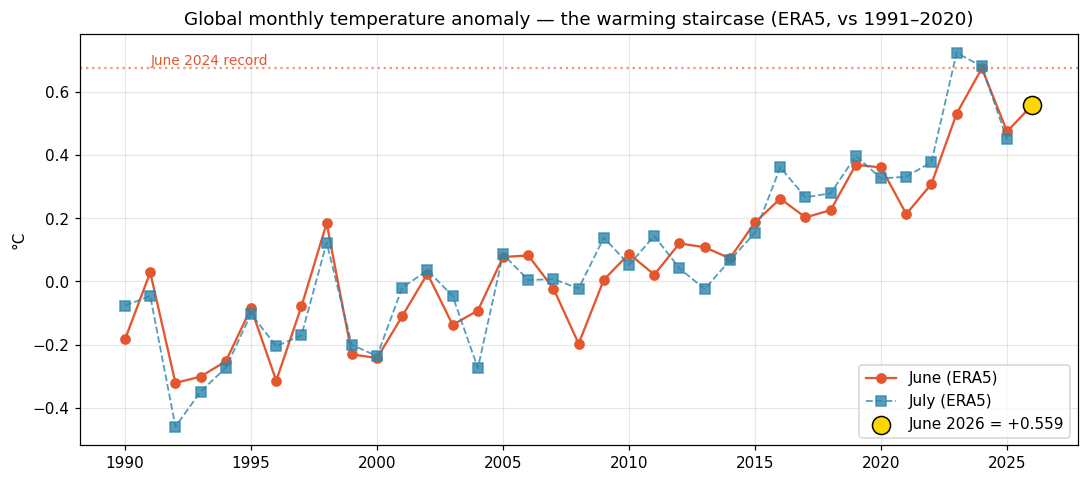

In [5]:
# ---- Trend table + chart ---------------------------------------------------
years = list(range(2014, 2027))
jun_vals = [era5_month(y,6)[0] for y in years]
jul_vals = [era5_month(y,7)[0] for y in years]
print(f"{'Year':<6}{'ERA5 June':>10}{'ERA5 July':>10}{'NOAA June':>10}{'NOAA July':>10}")
for y in years:
    j6, j7 = era5_month(y,6)[0], era5_month(y,7)[0]
    print(f"{y:<6}{j6:>+10.3f}{('' if j7 is None else format(j7,'+.3f')):>10}"
          f"{noaa_jun.get(y,''):>10}{noaa_jul.get(y,''):>10}")

fig, ax = plt.subplots(figsize=(10,4.5))
yy = list(range(1990, 2027))
ax.plot(yy, [era5_month(y,6)[0] for y in yy], 'o-', lw=1.5, color='#e4572e', label='June (ERA5)')
ax.plot(yy[:-1], [era5_month(y,7)[0] for y in yy[:-1]], 's--', lw=1.2, color='#2e86ab', alpha=.8, label='July (ERA5)')
ax.axhline(era5_month(2024,6)[0], color='#e4572e', ls=':', alpha=.6); ax.annotate('June 2024 record', (1991, era5_month(2024,6)[0]+.01), color='#e4572e', fontsize=9)
ax.scatter([2026],[jun26], s=140, zorder=5, color='gold', edgecolor='k', label=f'June 2026 = {jun26:+.3f}')
ax.set_title('Global monthly temperature anomaly — the warming staircase (ERA5, vs 1991–2020)')
ax.set_ylabel('°C'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
gap = jun26 - era5_month(2024,6)[0]
print(f"\nJune 2026 vs June 2024 record: {gap:+.4f} C  ({'BELOW' if gap<0 else 'ABOVE'} record)")

## §3 · The translation regression (ERA5 → NOAA)
The contract settles on NOAA, but the fresh data is ERA5 — two agencies measuring the same planet on different baselines with different methods. For each calendar month we fit **ordinary least squares** on 1990–2025 (36 paired observations):

$$\text{NOAA} = a + b\cdot\text{ERA5} + \varepsilon,\qquad
b=\frac{n\sum xy-\sum x\sum y}{n\sum x^2-(\sum x)^2},\quad a=\bar y - b\bar x$$

The **residual standard deviation** (dividing by $n\!-\!2$ for the two fitted parameters) measures how far NOAA typically lands from the line — the *irreducible dataset-disagreement risk*:

$$\sigma_{\text{resid}}=\sqrt{\frac{\sum_i \varepsilon_i^2}{n-2}}$$

Interpretation of the fit: intercept ≈ **0.58** = the baseline gap (1991–2020 floor vs 1901–2000 floor); slope ≈ **0.90** = NOAA's blend responds slightly less than 1:1 to ERA5 swings.

June : NOAA = 0.5851 + 0.9032 x ERA5   (residual SD = 0.0458 C, n=36)
July : NOAA = 0.5656 + 0.8923 x ERA5   (residual SD = 0.0356 C, n=36)


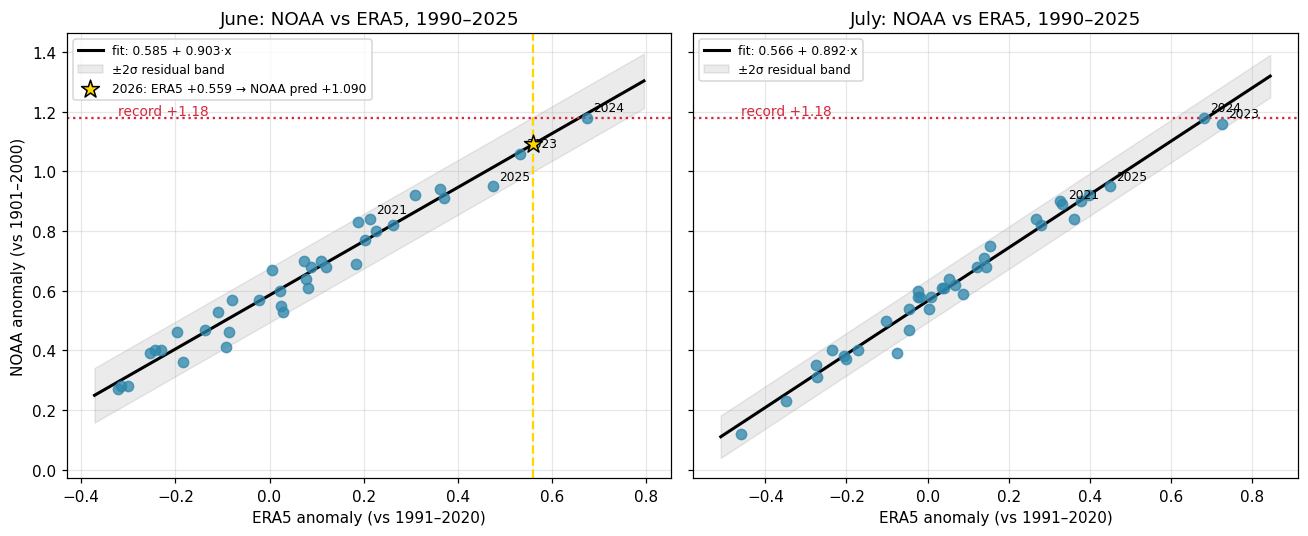

In [7]:
# ---- Fit both regressions, scatter plots ------------------------------------
FIT_YEARS = list(range(1990, 2026))
def ols(x, y):
    x, y = np.array(x), np.array(y)
    b = ((len(x)*np.sum(x*y) - x.sum()*y.sum()) / (len(x)*np.sum(x*x) - x.sum()**2))
    a = y.mean() - b*x.mean()
    resid = y - (a + b*x)
    sd = float(np.sqrt(np.sum(resid**2)/(len(x)-2)))
    return a, b, sd, resid

xj = [era5_month(y,6)[0] for y in FIT_YEARS]; yj = [noaa_jun[y] for y in FIT_YEARS]
xl = [era5_month(y,7)[0] for y in FIT_YEARS]; yl = [noaa_jul[y] for y in FIT_YEARS]
aJ, bJ, sdJ, resJ = ols(xj, yj)
aL, bL, sdL, resL = ols(xl, yl)
print(f"June : NOAA = {aJ:.4f} + {bJ:.4f} x ERA5   (residual SD = {sdJ:.4f} C, n={len(xj)})")
print(f"July : NOAA = {aL:.4f} + {bL:.4f} x ERA5   (residual SD = {sdL:.4f} C, n={len(xl)})")

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
for ax, x, y, a, b, sd, ttl, era26 in [
    (axes[0], xj, yj, aJ, bJ, sdJ, 'June', jun26),
    (axes[1], xl, yl, aL, bL, sdL, 'July', None)]:
    ax.scatter(x, y, s=45, color='#2e86ab', alpha=.75, zorder=3)
    xs = np.linspace(min(x)-.05, max(x)+.12, 50)
    ax.plot(xs, a+b*xs, 'k-', lw=2, label=f'fit: {a:.3f} + {b:.3f}·x')
    ax.fill_between(xs, a+b*xs-2*sd, a+b*xs+2*sd, color='k', alpha=.08, label='±2σ residual band')
    for yr in (2021, 2023, 2024, 2025):
        xi = era5_month(yr, 6 if ttl=='June' else 7)[0]
        yi = (noaa_jun if ttl=='June' else noaa_jul).get(yr)
        if yi: ax.annotate(str(yr), (xi, yi), fontsize=8, xytext=(4,4), textcoords='offset points')
    if era26 is not None:
        pred = a + b*era26
        ax.axvline(era26, color='gold', ls='--', lw=1.5)
        ax.scatter([era26],[pred], s=150, marker='*', color='gold', edgecolor='k', zorder=5,
                   label=f'2026: ERA5 {era26:+.3f} → NOAA pred {pred:+.3f}')
    rec = max(v for yy_,v in (noaa_jun if ttl=='June' else noaa_jul).items() if yy_<2026)
    ax.axhline(rec, color='#d7263d', ls=':', lw=1.5); ax.annotate(f'record {rec:+.2f}', (min(x), rec+.008), color='#d7263d', fontsize=9)
    ax.set_title(f'{ttl}: NOAA vs ERA5, 1990–2025'); ax.set_xlabel('ERA5 anomaly (vs 1991–2020)'); ax.grid(alpha=.3); ax.legend(fontsize=8)
axes[0].set_ylabel('NOAA anomaly (vs 1901–2000)')
plt.tight_layout()

June residuals — SD 0.0458 | largest + +0.080 | largest − -0.092 | mean last-5 yrs +0.0066
July residuals — SD 0.0356 | largest + +0.056 | largest − -0.107
Reading: no June residual in 36 years exceeded +0.07 — the +0.095 needed for a 2026 record would be unprecedented (before the §6 audit adjustment).


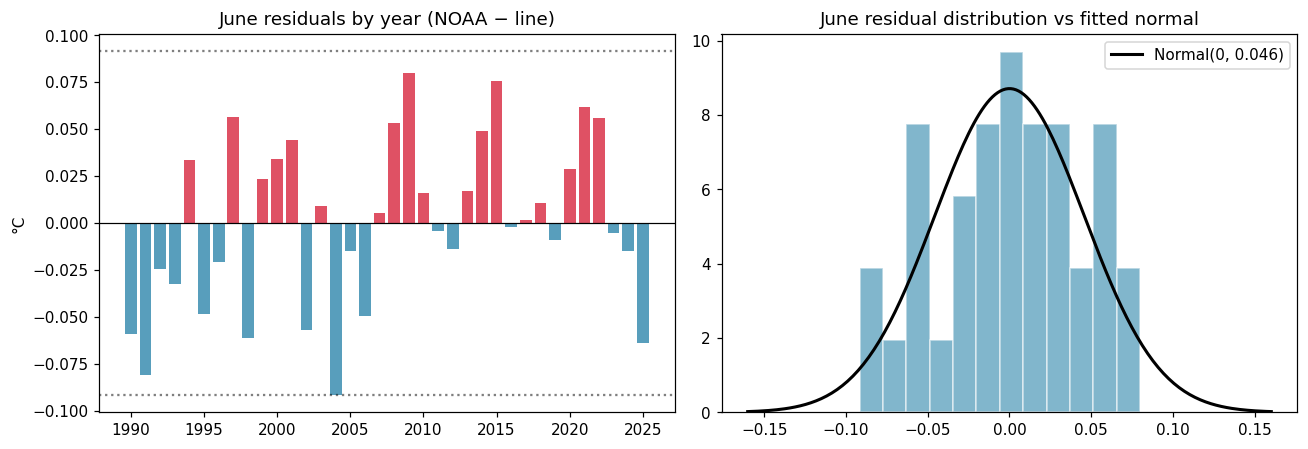

In [8]:
# ---- Residual diagnostics ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
axes[0].bar(FIT_YEARS, resJ, color=['#d7263d' if r>0 else '#2e86ab' for r in resJ], alpha=.8)
axes[0].axhline(0, color='k', lw=.8); axes[0].axhline(2*sdJ, color='k', ls=':', alpha=.5); axes[0].axhline(-2*sdJ, color='k', ls=':', alpha=.5)
axes[0].set_title('June residuals by year (NOAA − line)'); axes[0].set_ylabel('°C')
xs = np.linspace(-3.5*sdJ, 3.5*sdJ, 200)
axes[1].hist(resJ, bins=12, density=True, color='#2e86ab', alpha=.6, edgecolor='w')
axes[1].plot(xs, norm.pdf(xs, 0, sdJ), 'k-', lw=2, label=f'Normal(0, {sdJ:.3f})')
axes[1].set_title('June residual distribution vs fitted normal'); axes[1].legend()
plt.tight_layout()
print(f"June residuals — SD {sdJ:.4f} | largest + {max(resJ):+.3f} | largest − {min(resJ):+.3f} | mean last-5 yrs {np.mean(resJ[-5:]):+.4f}")
print(f"July residuals — SD {sdL:.4f} | largest + {max(resL):+.3f} | largest − {min(resL):+.3f}")
print("Reading: no June residual in 36 years exceeded +0.07 — the +0.095 needed for a 2026 record would be unprecedented (before the §6 audit adjustment).")

## §4 · From estimate to probability
Model the upcoming print as $X\sim\mathcal N(\mu,\sigma^2)$, with $\mu$ from the regression and $\sigma$ from the residuals (plus small ERA5 revision noise, combined in quadrature). NOAA prints **two decimals**, so beating a 1.18 record outright requires the underlying value $\ge 1.185$; the band $[1.175,1.185)$ prints "1.18" — a **tie**, which the Kalshi rules don't address (treated as a separate outcome).

$$Z=\frac{x_{\text{threshold}}-\mu}{\sigma}\qquad P(\text{YES})=1-\Phi(Z)$$

June 2026: mu = +1.0902, sigma = 0.0469, record = +1.18
Z = +2.02  ->  P(strict beat) = 2.2%   P(tie prints 1.18) = 1.4%


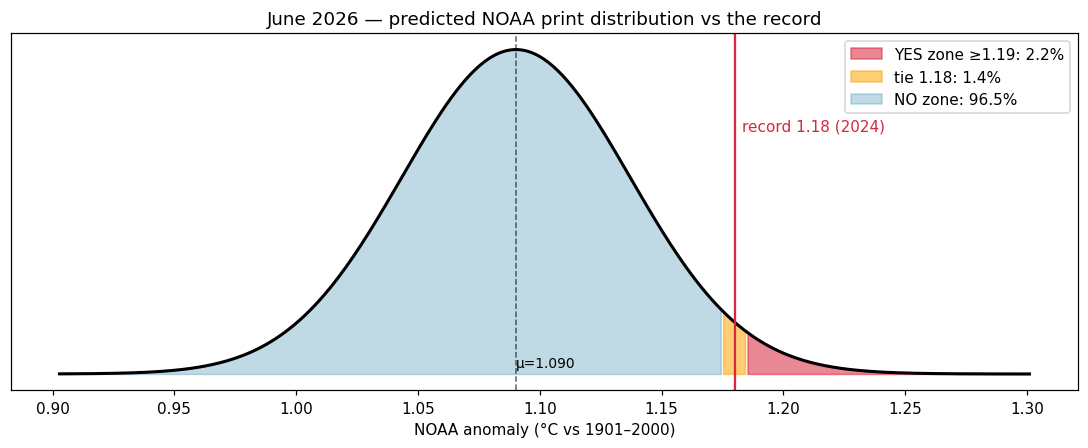

In [10]:
# ---- June probability ---------------------------------------------------------
recJ = max(v for y,v in noaa_jun.items() if y < 2026)
muJ  = aJ + bJ*jun26
sJ   = math.hypot(sdJ, 0.01)               # + ERA5T final-revision allowance
Zj   = (recJ + 0.005 - muJ)/sJ
p_beat = 1 - norm.cdf(Zj)
p_tie  = norm.cdf((recJ+.005-muJ)/sJ) - norm.cdf((recJ-.005-muJ)/sJ)
print(f"June 2026: mu = {muJ:+.4f}, sigma = {sJ:.4f}, record = {recJ:+.2f}")
print(f"Z = {Zj:+.2f}  ->  P(strict beat) = {p_beat*100:.1f}%   P(tie prints 1.18) = {p_tie*100:.1f}%")

fig, ax = plt.subplots(figsize=(10,4.2))
xs = np.linspace(muJ-4*sJ, muJ+4.5*sJ, 400)
ax.plot(xs, norm.pdf(xs, muJ, sJ), 'k-', lw=2)
ax.fill_between(xs, 0, norm.pdf(xs, muJ, sJ), where=xs>=recJ+.005, color='#d7263d', alpha=.55, label=f'YES zone ≥1.19: {p_beat*100:.1f}%')
ax.fill_between(xs, 0, norm.pdf(xs, muJ, sJ), where=(xs>=recJ-.005)&(xs<recJ+.005), color='orange', alpha=.55, label=f'tie 1.18: {p_tie*100:.1f}%')
ax.fill_between(xs, 0, norm.pdf(xs, muJ, sJ), where=xs<recJ-.005, color='#2e86ab', alpha=.30, label=f'NO zone: {(1-p_beat-p_tie)*100:.1f}%')
ax.axvline(muJ, color='k', ls='--', lw=1, alpha=.6); ax.annotate(f'μ={muJ:.3f}', (muJ, ax.get_ylim()[1]*.02), fontsize=9)
ax.axvline(recJ, color='#d7263d', ls='-', lw=1.5); ax.annotate(f'record {recJ:.2f} (2024)', (recJ+.003, norm.pdf(muJ,muJ,sJ)*.75), color='#d7263d')
ax.set_title('June 2026 — predicted NOAA print distribution vs the record')
ax.set_xlabel('NOAA anomaly (°C vs 1901–2000)'); ax.legend(); ax.set_yticks([])
plt.tight_layout()

## §5 · July: forecasting an unfinished month
July adds *weather risk* on top of translation risk. Historical two-predictor regression — *given last month's mean and the first $k$ observed days, where does the full month land?*

$$\text{July}_{\text{full}} = c_0 + c_1\cdot\text{June} + c_2\cdot\overline{\text{first }k\text{ days}}$$

Errors then **chain in quadrature** through the translation line:
$\sigma_{\text{NOAA}} = \sqrt{(b\cdot\sigma_{\text{forecast}})^2+\sigma_{\text{resid}}^2}$.
As $k$ grows, $c_2\to 1$, $c_1\to 0$ and $\sigma_{\text{forecast}}$ **collapses** — the k-days schedule tells you *when* re-checking is worth it.

k = 4 July days observed; weights: prev-month 0.70, first-4 days 0.37
ERA5 July forecast: +0.6372 ± 0.0851
NOAA July 2026 ~ N(+1.1341, 0.0839) vs record +1.18  ->  Z = +0.61,  P(YES) = 27.2%


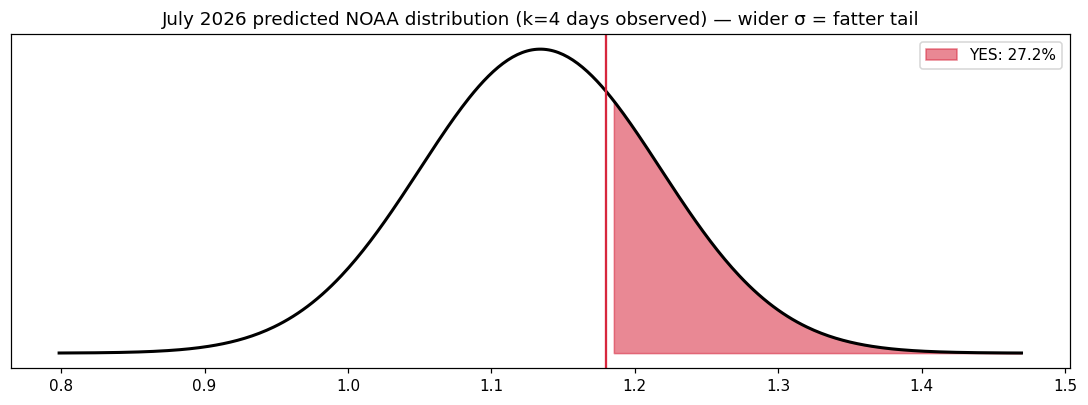

In [12]:
# ---- July conditional forecast (uses however many July days exist today) -----
def fit_july_given_k(k):
    X1 = [era5_month(y,6)[0] for y in FIT_YEARS]
    X2 = [np.mean([daily[(y,7)][d] for d in range(1,k+1)]) for y in FIT_YEARS]
    Y  = [era5_month(y,7)[0] for y in FIT_YEARS]
    A  = np.column_stack([np.ones(len(Y)), X1, X2])
    coef, *_ = np.linalg.lstsq(A, np.array(Y), rcond=None)
    pred = A @ coef
    sd = float(np.sqrt(np.sum((Y-pred)**2)/(len(Y)-3)))
    return coef, sd

k = k_jul if k_jul >= 1 else 1
coef, sd_f = fit_july_given_k(k)
first_k = np.mean([daily[(2026,7)][d] for d in range(1, k+1)])
era_jul = coef[0] + coef[1]*jun26 + coef[2]*first_k
muL = aL + bL*era_jul
sL  = math.hypot(bL*sd_f, sdL)
recL = max(v for y,v in noaa_jul.items() if y < 2026)
ZL = (recL + .005 - muL)/sL
pL = 1 - norm.cdf(ZL)
print(f"k = {k} July days observed; weights: prev-month {coef[1]:.2f}, first-{k} days {coef[2]:.2f}")
print(f"ERA5 July forecast: {era_jul:+.4f} ± {sd_f:.4f}")
print(f"NOAA July 2026 ~ N({muL:+.4f}, {sL:.4f}) vs record {recL:+.2f}  ->  Z = {ZL:+.2f},  P(YES) = {pL*100:.1f}%")

fig, ax = plt.subplots(figsize=(10,3.8))
xs = np.linspace(muL-4*sL, muL+4*sL, 400)
ax.plot(xs, norm.pdf(xs, muL, sL), 'k-', lw=2)
ax.fill_between(xs, 0, norm.pdf(xs, muL, sL), where=xs>=recL+.005, color='#d7263d', alpha=.55, label=f'YES: {pL*100:.1f}%')
ax.axvline(recL, color='#d7263d', lw=1.5); ax.set_yticks([]); ax.legend()
ax.set_title(f'July 2026 predicted NOAA distribution (k={k} days observed) — wider σ = fatter tail')
plt.tight_layout()

Day-15 decision table (July 1–15 ERA5 running mean -> fair NO):
  running mean +0.55 -> P(YES)   3.8%   fair NO  96.2c
  running mean +0.58 -> P(YES)   9.7%   fair NO  90.3c
  running mean +0.60 -> P(YES)  16.3%   fair NO  83.7c
  running mean +0.62 -> P(YES)  25.3%   fair NO  74.7c
  running mean +0.64 -> P(YES)  36.3%   fair NO  63.7c
  running mean +0.66 -> P(YES)  48.5%   fair NO  51.5c
  running mean +0.68 -> P(YES)  61.0%   fair NO  39.0c
  running mean +0.70 -> P(YES)  72.3%   fair NO  27.7c


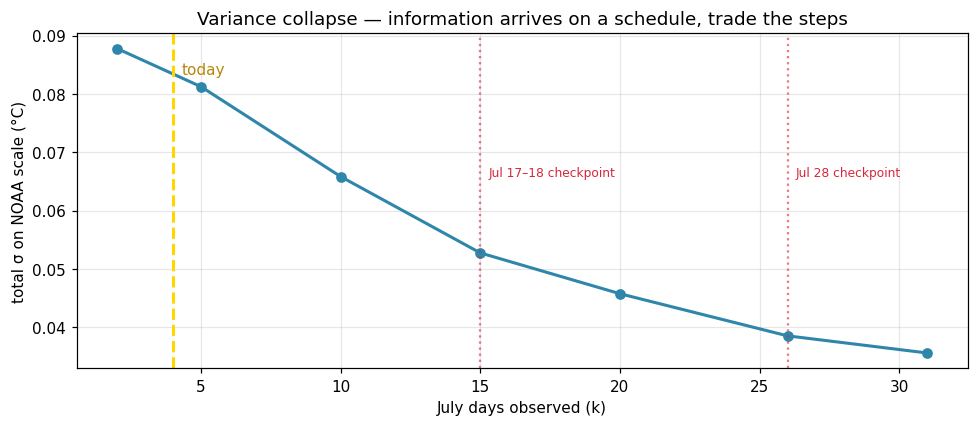

In [13]:
# ---- Variance collapse: how uncertainty dies as July fills in ------------------
ks = [2,5,10,15,20,26,31]
sds = []
for kk in ks:
    if kk > 31: continue
    _, s = fit_july_given_k(min(kk,31))
    sds.append(math.hypot(bL*s, sdL))
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(ks[:len(sds)], sds, 'o-', lw=2, color='#2e86ab')
ax.axvline(k, color='gold', lw=2, ls='--'); ax.annotate('today', (k+.3, max(sds)*.95), color='#b8860b')
for kk, dt in [(15,'Jul 17–18 checkpoint'), (26,'Jul 28 checkpoint')]:
    ax.axvline(kk, color='#d7263d', ls=':', alpha=.6); ax.annotate(dt, (kk+.3, max(sds)*.75), fontsize=8, color='#d7263d')
ax.set_xlabel('July days observed (k)'); ax.set_ylabel('total σ on NOAA scale (°C)')
ax.set_title('Variance collapse — information arrives on a schedule, trade the steps'); ax.grid(alpha=.3)
plt.tight_layout()
print("Day-15 decision table (July 1–15 ERA5 running mean -> fair NO):")
c15, s15 = fit_july_given_k(15); sN15 = math.hypot(bL*s15, sdL)
for track in [0.55,0.58,0.60,0.62,0.64,0.66,0.68,0.70]:
    m = aL + bL*(c15[0] + c15[1]*jun26 + c15[2]*track)
    p = 1 - norm.cdf((recL+.005-m)/sN15)
    print(f"  running mean {track:+.2f} -> P(YES) {p*100:5.1f}%   fair NO {100*(1-p):5.1f}c")

## §6 · The 2026 audit — testing the model against reality
NOAA has already printed **five 2026 months**. Fitting a separate translation line per calendar month and predicting 2026 gives an out-of-sample scorecard. Result: NOAA ran **+0.020 °C warm on average** (never cold) vs the historical mapping — an *operational bias* that widens honest fair value. Counterweights: the bias concentrated in Feb–Apr (high Arctic-divergence months), and June 2025's own residual was −0.064. Hence a **bracket, not a point**: June fair YES ≈ 2.5–8%.

Month   ERA5 2026    pred   NOAA   resid
1          +0.510   1.096   1.10  +0.004
2          +0.536   1.147   1.17  +0.023
3          +0.534   1.171   1.22  +0.049
4          +0.523   1.116   1.14  +0.024
5          +0.546   1.070   1.07  -0.000

Mean 2026 operational bias: +0.0198 C

Sensitivity table — June & July P(YES) under adjustment scenarios:
scenario                     June P(YES) July P(YES)
base model                          2.2%       27.2%
audit bias (+0.020)                 5.5%       35.5%
bias + ENSO tilt (July)             5.5%       43.7%


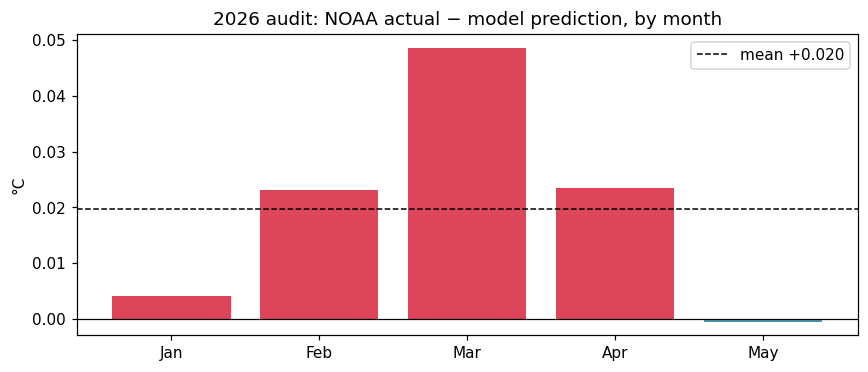

In [15]:
# ---- Audit + sensitivity --------------------------------------------------------
biases = []
print(f"{'Month':<7}{'ERA5 2026':>10}{'pred':>8}{'NOAA':>7}{'resid':>8}")
for m in range(1, 6):
    nm = noaa_series(m)
    x = [era5_month(y,m)[0] for y in FIT_YEARS]; yv = [nm[y] for y in FIT_YEARS]
    a_, b_, sd_, _ = ols(x, yv)
    pred = a_ + b_*era5_month(2026,m)[0]
    resid = nm[2026] - pred
    biases.append(resid)
    print(f"{m:<7}{era5_month(2026,m)[0]:>+10.3f}{pred:>8.3f}{nm[2026]:>7.2f}{resid:>+8.3f}")
bias = float(np.mean(biases))
print(f"\nMean 2026 operational bias: {bias:+.4f} C")

fig, ax = plt.subplots(figsize=(8,3.5))
ax.bar(['Jan','Feb','Mar','Apr','May'], biases, color=['#d7263d' if b>0 else '#2e86ab' for b in biases], alpha=.85)
ax.axhline(0, color='k', lw=.8); ax.axhline(bias, color='k', ls='--', lw=1, label=f'mean {bias:+.3f}')
ax.set_title('2026 audit: NOAA actual − model prediction, by month'); ax.set_ylabel('°C'); ax.legend()
plt.tight_layout()

print("\nSensitivity table — June & July P(YES) under adjustment scenarios:")
print(f"{'scenario':<28}{'June P(YES)':>12}{'July P(YES)':>12}")
for name, addJ, addL in [('base model', 0, 0), ('audit bias (+0.020)', bias, bias), ('bias + ENSO tilt (July)', bias, bias + bL*0.02)]:
    pj = 1 - norm.cdf((recJ+.005-(muJ+addJ))/sJ)
    pl = 1 - norm.cdf((recL+.005-(muL+addL))/sL)
    print(f"{name:<28}{pj*100:>11.1f}%{pl*100:>11.1f}%")

## §7 · Money: expected value, fees, Kelly
Binary contract: **fair price (¢) = probability (%)**. For a NO bought at ask $c$ with win probability $p$:
$$EV = p\cdot\$1 - c - \text{fee},\qquad \text{fee} \approx 0.07\,c\,(1-c)\ \text{per contract}$$
Kelly fraction for a binary (odds $b=(1-c)/c$): $f^\*=\dfrac{p(1+b)-1}{b}$ — **always cut to ¼ or less**, because Kelly assumes $p$ is exact and §6 proved ours has a disputed knob.

JUNE — EV per $ NO contract at various asks under three probability scenarios
 NO ask |    optimistic 2.2% |       central 5.0% |   pessimistic 8.0% |  1/4-Kelly (central)
    84c |            +0.129$ |            +0.101$ |            +0.071$ |   17.2% of bankroll
    86c |            +0.110$ |            +0.082$ |            +0.052$ |   16.1% of bankroll
    88c |            +0.091$ |            +0.063$ |            +0.033$ |   14.6% of bankroll
    90c |            +0.072$ |            +0.044$ |            +0.014$ |   12.5% of bankroll
    92c |            +0.053$ |            +0.025$ |            -0.005$ |    9.4% of bankroll
    94c |            +0.034$ |            +0.006$ |            -0.024$ |    4.2% of bankroll

Breakeven P(YES) by ask (edge=0, incl. fee):
  NO at 84c breaks even iff true P(YES) = 15.1%
  NO at 88c breaks even iff true P(YES) = 11.3%
  NO at 90c breaks even iff true P(YES) = 9.4%
  NO at 92c breaks even iff true P(YES) = 7.5%


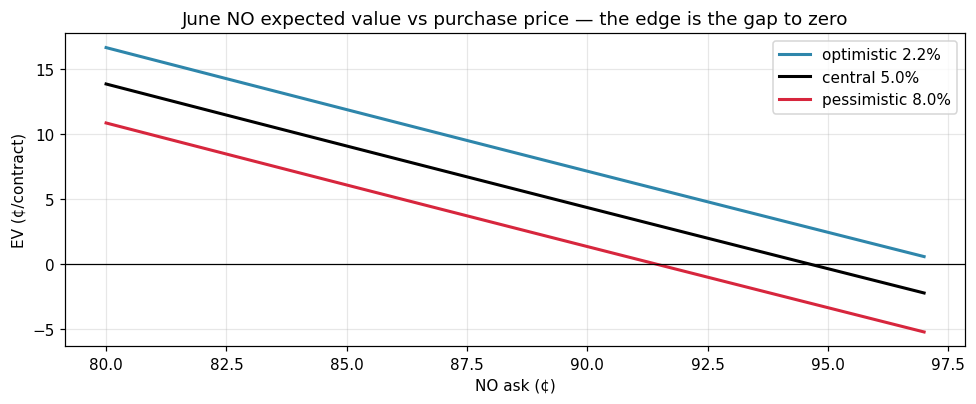

In [17]:
# ---- EV / Kelly tables ------------------------------------------------------------
def ev_no(ask, p_yes):
    fee = 0.07*ask*(1-ask)
    return (1-p_yes) - ask - fee
def kelly_no(ask, p_yes):
    b = (1-ask)/ask
    return max(0.0, ((1-p_yes)*(1+b)-1)/b)

print("JUNE — EV per $ NO contract at various asks under three probability scenarios")
scen = [('optimistic 2.2%', .022), ('central 5.0%', .05), ('pessimistic 8.0%', .08)]
print(f"{'NO ask':>7} | " + " | ".join(f"{n:>18}" for n,_ in scen) + " |  1/4-Kelly (central)")
for ask in [.84,.86,.88,.90,.92,.94]:
    row = " | ".join(f"{ev_no(ask,p):>+17.3f}$" for _,p in scen)
    print(f"{ask*100:>6.0f}c | {row} | {kelly_no(ask,.05)/4*100:>6.1f}% of bankroll")
print("\nBreakeven P(YES) by ask (edge=0, incl. fee):")
for ask in [.84,.88,.90,.92]:
    fee = .07*ask*(1-ask)
    print(f"  NO at {ask*100:.0f}c breaks even iff true P(YES) = {(1-ask-fee)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9,3.8))
asks = np.linspace(.80,.97,60)
for (n,p),c in zip(scen, ['#2e86ab','k','#d7263d']):
    ax.plot(asks*100, [ev_no(a,p)*100 for a in asks], lw=2, color=c, label=n)
ax.axhline(0,color='k',lw=.8); ax.set_xlabel('NO ask (¢)'); ax.set_ylabel('EV (¢/contract)')
ax.set_title('June NO expected value vs purchase price — the edge is the gap to zero'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()

## §8 · Summary card & limitations
**Pipeline:** ERA5 daily → monthly mean → (partial-month forecast) → translation line → $\mathcal N(\mu,\sigma)$ → tail vs record → fair price → edge vs book → fractional-Kelly size.

**Known limitations (read before trusting):** normality of a 36-sample residual set (fat tails plausible) · stationarity of the ERA5↔NOAA mapping (§6 caught real drift, patched with a knob) · global-scalar input (a gridded GHCN+ERSST replication achieves ±0.02 vs our ±0.047) · small-sample adjustments (bias: 5 points; ENSO tilt: 5 analog years).

**Operating calendar:** NOAA June print **Jul 9** (June market settles) · Day-15 checkpoint **Jul 17–18** · Day-26 checkpoint **Jul 28** (market still open, σ≈0.017) · July print ~**Aug 13**. Re-run with `REFRESH=True` at each checkpoint.

In [19]:
# ---- Live summary card (recomputes from whatever data is loaded) -----------------
print("="*72)
print(f"  HOTTEST-MONTH MODEL — summary  (data through {last_day[0]}-{last_day[1]:02d}-{last_day[2]:02d})")
print("="*72)
print(f"  JUNE 2026 : ERA5 {jun26:+.3f} (complete) -> NOAA mu {muJ:+.3f} ± {sJ:.3f}")
print(f"              record {recJ:+.2f} | Z {Zj:+.2f} | P(beat) {p_beat*100:.1f}% | P(tie) {p_tie*100:.1f}%")
print(f"              audit-adjusted P(beat): {(1-norm.cdf((recJ+.005-muJ-bias)/sJ))*100:.1f}%   fair NO: {100*(1-(1-norm.cdf((recJ+.005-muJ-bias)/sJ))):.0f}-{100*(1-p_beat):.0f}c")
print(f"  JULY 2026 : ERA5 fcst {era_jul:+.3f} ± {sd_f:.3f} (k={k}) -> NOAA mu {muL:+.3f} ± {sL:.3f}")
print(f"              record {recL:+.2f} | Z {ZL:+.2f} | P(YES) {pL*100:.1f}% (base) — see §6 sensitivity")
print("="*72)

  HOTTEST-MONTH MODEL — summary  (data through 2026-07-04)
  JUNE 2026 : ERA5 +0.559 (complete) -> NOAA mu +1.090 ± 0.047
              record +1.18 | Z +2.02 | P(beat) 2.2% | P(tie) 1.4%
              audit-adjusted P(beat): 5.5%   fair NO: 95-98c
  JULY 2026 : ERA5 fcst +0.637 ± 0.085 (k=4) -> NOAA mu +1.134 ± 0.084
              record +1.18 | Z +0.61 | P(YES) 27.2% (base) — see §6 sensitivity
